Costruzione del circuito FULL-ADDER

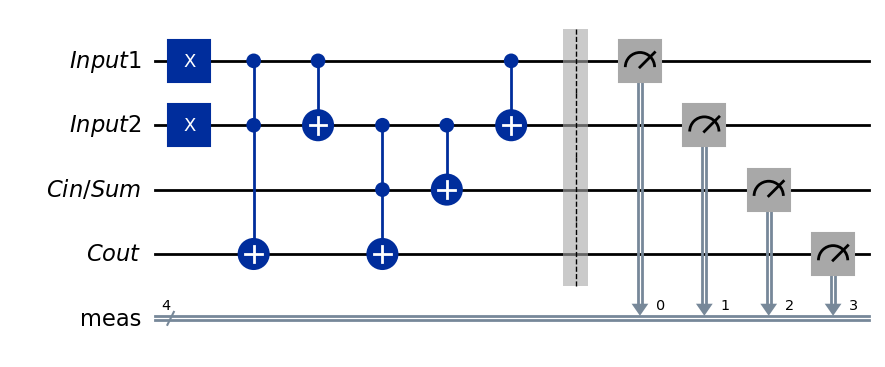

In [18]:
from qiskit import QuantumCircuit, transpile, QuantumRegister

# Creo il circuito FULL-ADDER dando i nomi ai vari qubit per chiarezza
qr_inp1 = QuantumRegister(1, name='Input1')
qr_inp2 = QuantumRegister(1, name='Input2')
qr_cin_sum = QuantumRegister(1,name='Cin/Sum')
qr_cout = QuantumRegister(1,name='Cout')
qc = QuantumCircuit(qr_inp1, qr_inp2, qr_cin_sum,qr_cout)


# Il circuito sarà testato con gli input da sommare nello stato a 1
qc.x(0)
qc.x(1)


# Struttura con funzione di FULL-ADDER
qc.ccx(0,1,3)
qc.cx(0,1)
qc.ccx(1,2,3)
qc.cx(1,2)
qc.cx(0,1)

qc.measure_all()
qc.draw("mpl")

In [19]:
from qiskit_aer import AerSimulator

simulator = AerSimulator()
qc_test_op0 = transpile(qc, simulator, optimization_level=0)
job = simulator.run(qc_test_op0, shots=1024)
counts = job.result().get_counts()

print(counts)

{'1011': 1024}


Costruisco il simulatore partendo dalla backend fisica backend_kingston

In [ ]:
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_aer.noise import NoiseModel

# Simuleremo il nostro circuito utilizzando come riferimento IBM_kingston
service = QiskitRuntimeService()
backend_kingston = service.backend('ibm_kingston')
noise_model = NoiseModel.from_backend(backend_kingston)
noise_kingston_sim = AerSimulator(noise_model=noise_model)

qiskit_runtime_service.__init__:WARNING:2026-04-02 16:54:54,478: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-04-02 16:54:54,479: Using instance: open-instance, plan: open


Differenza nei gate utilizzati per i 4 transpile con i diversi optimization_level

In [21]:
qc_transpiled_0 = transpile(qc, backend_kingston, optimization_level=0)
qc_transpiled_1 = transpile(qc, backend_kingston, optimization_level=1)
qc_transpiled_2 = transpile(qc, backend_kingston, optimization_level=2)
qc_transpiled_3 = transpile(qc, backend_kingston, optimization_level=3)
print("\nDifferenza nei gate usati:")
print("optimization_level=0",qc_transpiled_0.count_ops())
print("optimization_level=1",qc_transpiled_1.count_ops())
print("optimization_level=1",qc_transpiled_2.count_ops())
print("optimization_level=3",qc_transpiled_3.count_ops())


Differenza nei gate usati:
optimization_level=0 OrderedDict({'rz': 82, 'sx': 58, 'cz': 27, 'measure': 4, 'x': 2, 'barrier': 1})
optimization_level=1 OrderedDict({'rz': 37, 'sx': 30, 'cz': 17, 'measure': 4, 'x': 2, 'barrier': 1})
optimization_level=1 OrderedDict({'sx': 27, 'rz': 25, 'cz': 17, 'x': 4, 'measure': 4, 'barrier': 1})
optimization_level=3 OrderedDict({'sx': 27, 'rz': 25, 'cz': 17, 'x': 4, 'measure': 4, 'barrier': 1})


Ricavo il rumore del QC in base ai 4 livelli di ottimizzazione

In [22]:
# Dati sul rumore con optimization_level=0

# inizializzo le liste per le probabilità del valore associato alla max probabilità (si presuppone quello corretto del qc) e il rumore
max_prob_values = []
noise_values = []
# Anche se richiede più tempo preferiamo eseguire 10 iterazioni poichè il nostro focus è sugli optimization_level ed è quindi importante che non si esegua
# la simulazione 1000 volte sullo stesso circuito transpilato, ma piuttosto su 10 circuiti tranpilati diversi, ma con uguali 
# parametri e si prenda poi la media della probabilità del valore desiderato. Così facendo essendo l'ottimizzazione euristica evitiamo 
# che la singola transpilazione 'fortunata' o 'sfortunata' ci faccia osservare valori non del tutto significativi
for _ in range(10):
    qc_transpiled = transpile(qc, backend_kingston, optimization_level=0)
    job = noise_kingston_sim.run(qc_transpiled, shots=1000)
    counts = job.result().get_counts()
    # Da 'counts' raccolgo le probabilità e gli stati associati ad esse
    probabilities = {key: value / 1000 for key, value in counts.items()} 
    # Trovo la max probabilità e il valore a cui è associata (si presuppone quello corretto del qc)
    max_prob_state = max(probabilities, key=probabilities.get)
    max_prob_value = probabilities[max_prob_state]
    # Raccolgo le probabilità di tutti gli altri stati sotto un unico valore detto 'noises_prob' così da avere un grafico più chiaro
    noises_prob = sum(prob for state, prob in probabilities.items() if state != max_prob_state)
    # Aggiungo alle nostre liste
    max_prob_values.append(max_prob_value)
    noise_values.append(noises_prob)
# Calcolo la media delle probabilità del valore corretto e del rumore
average_max_prob_value = sum(max_prob_values) / len(max_prob_values)
average_noise_value = sum(noise_values) / len(noise_values)
# Unisco le informazioni in un unico dato
probabilities_level_0 = {max_prob_state: average_max_prob_value, 'noise': average_noise_value}

# Dati sul rumore con optimization_level=1
max_prob_values = []
noise_values = []
for _ in range(10):
    qc_transpiled = transpile(qc, backend_kingston, optimization_level=1)
    job = noise_kingston_sim.run(qc_transpiled, shots=1000)
    counts = job.result().get_counts()
    probabilities = {key: value / 1000 for key, value in counts.items()} 
    max_prob_state = max(probabilities, key=probabilities.get)
    max_prob_value = probabilities[max_prob_state]
    noises_prob = sum(prob for state, prob in probabilities.items() if state != max_prob_state)
    max_prob_values.append(max_prob_value)
    noise_values.append(noises_prob)
average_max_prob_value = sum(max_prob_values) / len(max_prob_values)
average_noise_value = sum(noise_values) / len(noise_values)
probabilities_level_1 = {max_prob_state: average_max_prob_value, 'noise': average_noise_value}

# Dati sul rumore con optimization_level=2
max_prob_values = []
noise_values = []
for _ in range(10):
    qc_transpiled = transpile(qc, backend_kingston, optimization_level=2)
    job = noise_kingston_sim.run(qc_transpiled, shots=1000)
    counts = job.result().get_counts()
    probabilities = {key: value / 1000 for key, value in counts.items()} 
    max_prob_state = max(probabilities, key=probabilities.get)
    max_prob_value = probabilities[max_prob_state]
    noises_prob = sum(prob for state, prob in probabilities.items() if state != max_prob_state)
    max_prob_values.append(max_prob_value)
    noise_values.append(noises_prob)
average_max_prob_value = sum(max_prob_values) / len(max_prob_values)
average_noise_value = sum(noise_values) / len(noise_values)
probabilities_level_2 = {max_prob_state: average_max_prob_value, 'noise': average_noise_value}

# Dati sul rumore con optimization_level=3
max_prob_values = []
noise_values = []
for _ in range(10):
    qc_transpiled = transpile(qc, backend_kingston, optimization_level=3)
    job = noise_kingston_sim.run(qc_transpiled, shots=1000)
    counts = job.result().get_counts()
    probabilities = {key: value / 1000 for key, value in counts.items()} 
    max_prob_state = max(probabilities, key=probabilities.get)
    max_prob_value = probabilities[max_prob_state]
    noises_prob = sum(prob for state, prob in probabilities.items() if state != max_prob_state)
    max_prob_values.append(max_prob_value)
    noise_values.append(noises_prob)
average_max_prob_value = sum(max_prob_values) / len(max_prob_values)
average_noise_value = sum(noise_values) / len(noise_values)
probabilities_level_3 = {max_prob_state: average_max_prob_value, 'noise': average_noise_value}

Confronto tra valore desiderato e rumore in base ai diversi gradi di Optimization_Level

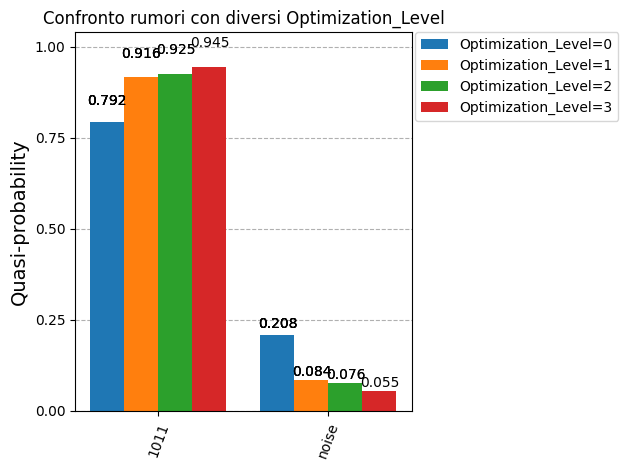

In [23]:
data = [probabilities_level_0,probabilities_level_1,probabilities_level_2, probabilities_level_3]
legend_labels = ["Optimization_Level=0", "Optimization_Level=1","Optimization_Level=2", "Optimization_Level=3"]
plot_histogram(data, legend=legend_labels, title="Confronto rumori con diversi Optimization_Level")

Eseguiremo lo stesso procedimento sul rumore, ma eseguito su hardware reale
Per prima cosa Esecuzione su hardware reale backend_kingston con i 4 livelli di optimization_level

from qiskit_ibm_runtime import SamplerV2

qc_transpiled = transpile(qc, backend_kingston, optimization_level=0,scheduling_method="alap")
sampler = SamplerV2(backend_kingston)
job_real = sampler.run([qc_transpiled], shots=1000)
print("Job ID:", job_real.job_id())

qc_transpiled = transpile(qc, backend_kingston, optimization_level=1,scheduling_method="alap")
sampler = SamplerV2(backend_kingston)
job_real = sampler.run([qc_transpiled], shots=1000)
print("Job ID:", job_real.job_id())

qc_transpiled = transpile(qc, backend_kingston, optimization_level=2,scheduling_method="alap")
sampler = SamplerV2(backend_kingston)
job_real = sampler.run([qc_transpiled], shots=1000)
print("Job ID:", job_real.job_id())

qc_transpiled = transpile(qc, backend_kingston, optimization_level=3,scheduling_method="alap")
sampler = SamplerV2(backend_kingston)
job_real = sampler.run([qc_transpiled], shots=1000)
print("Job ID:", job_real.job_id())

Recupero dei dati delle esecuzioni su hardware reale

In [ ]:
job_id = 'xxxxxxxxxxxxxxxxxx'
job_real=service.job(job_id)
results_real_0=job_real.result()

job_id = 'xxxxxxxxxxxxxxxxxx'
job_real=service.job(job_id)
results_real_1=job_real.result()

job_id = 'xxxxxxxxxxxxxxxxxx'
job_real=service.job(job_id)
results_real_2=job_real.result()

job_id = 'xxxxxxxxxxxxxxxxxx'
job_real=service.job(job_id)
results_real_3=job_real.result()

Confronto dei rumori in base ai diversi gradi di Optimization_Level

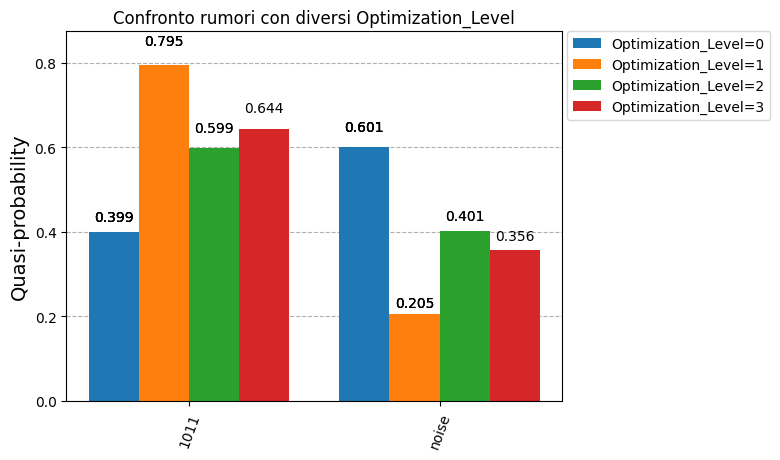

In [30]:
# Codice analogo a quello con simulatore
counts = results_real_0[0].data.meas.get_counts()
probabilities = {key: value / 10000 for key, value in counts.items()}
max_prob_state = max(probabilities, key=probabilities.get) 
max_prob_value = probabilities[max_prob_state]  
noises_prob = sum(prob for state, prob in probabilities.items() if state != max_prob_state) 
probabilities_level_0 = {max_prob_state: max_prob_value, 'noise': noises_prob}

counts = results_real_1[0].data.meas.get_counts()
probabilities = {key: value / 10000 for key, value in counts.items()}
max_prob_state = max(probabilities, key=probabilities.get)  
max_prob_value = probabilities[max_prob_state] 
noises_prob = sum(prob for state, prob in probabilities.items() if state != max_prob_state) 
probabilities_level_1 = {max_prob_state: max_prob_value, 'noise': noises_prob}

counts = results_real_2[0].data.meas.get_counts()
probabilities = {key: value / 10000 for key, value in counts.items()}
max_prob_state = max(probabilities, key=probabilities.get)  
max_prob_value = probabilities[max_prob_state] 
noises_prob = sum(prob for state, prob in probabilities.items() if state != max_prob_state) 
probabilities_level_2 = {max_prob_state: max_prob_value, 'noise': noises_prob}

counts = results_real_3[0].data.meas.get_counts()
probabilities = {key: value / 10000 for key, value in counts.items()}
max_prob_state = max(probabilities, key=probabilities.get)  
max_prob_value = probabilities[max_prob_state] 
noises_prob = sum(prob for state, prob in probabilities.items() if state != max_prob_state) 
probabilities_level_3 = {max_prob_state: max_prob_value, 'noise': noises_prob}

data = [probabilities_level_0,probabilities_level_1,probabilities_level_2, probabilities_level_3]
legend_labels = ["Optimization_Level=0", "Optimization_Level=1","Optimization_Level=2", "Optimization_Level=3"]
plot_histogram(data, legend=legend_labels, title="Confronto rumori con diversi Optimization_Level")


Profondità del QC e #Gates in base ai 4 livelli di ottimizzazione di Qiskit

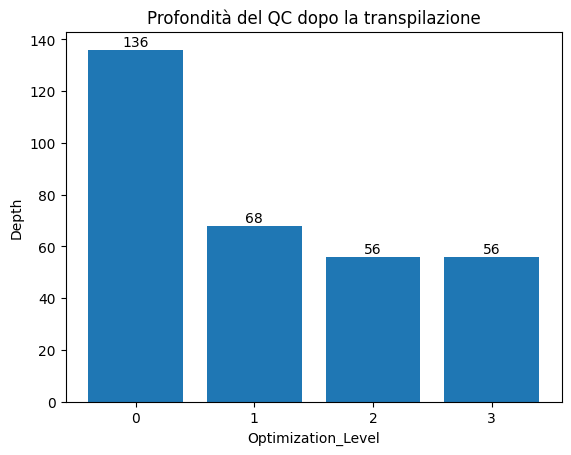

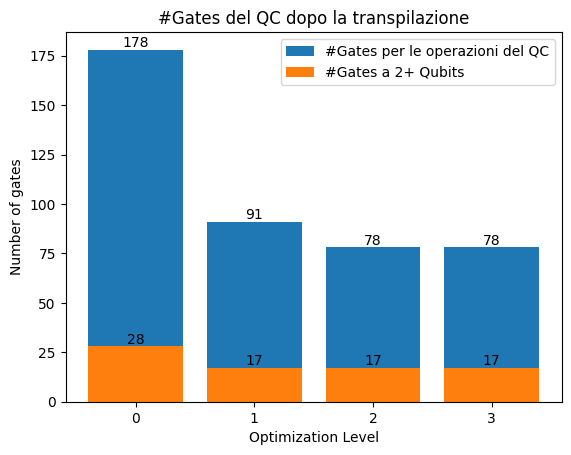

In [25]:
import matplotlib.pyplot as plt

depths = [0,0,0,0]
gate_counts = [0,0,0,0]
non_local_gate_counts = [0,0,0,0]
levels = ["0", "1", "2", "3"]

# Eseguo la traspilazione sempre basata su ibm_kingston e raccolgo la profondità e #Gates per ogni optimization_level facendo una media su 10 transpilazioni
for i in range(10):
    for level in range(4):
        circ = transpile(qc, backend_kingston, optimization_level=level)
        depths[level] += circ.depth()
        gate_counts[level] += sum(circ.count_ops().values())
        non_local_gate_counts[level] += circ.num_nonlocal_gates()

for i in range(4):
    depths[i] = round(depths[i]/10)
    gate_counts[i] = round(gate_counts[i]/10)
    non_local_gate_counts[i] = round(non_local_gate_counts[i]/10)

# Grafico per la Profondità
plt.figure()
bars = plt.bar(levels, depths, label='Depth')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 2), ha='center', va='bottom', fontsize=10)
plt.xlabel("Optimization_Level")
plt.ylabel("Depth")
plt.title("Profondità del QC dopo la transpilazione")
plt.show()
# Grafico per il #Gates
plt.figure()
bars = plt.bar(levels, gate_counts, label='#Gates per le operazioni del QC')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 2), ha='center', va='bottom', fontsize=10)
bars = plt.bar(levels, non_local_gate_counts, label='#Gates a 2+ Qubits ')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 2), ha='center', va='bottom', fontsize=10)
plt.xlabel("Optimization Level")
plt.ylabel("Number of gates")
plt.legend()
plt.title("#Gates del QC dopo la transpilazione")
plt.show()

Confronto dei tempi di esecuzione in base ai diversi 'Optimization_Level' sfruttando 'scheduled_circuit' prendendo come riferimento sempre ibm_kingston

In [27]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

exec_times = [0,0,0,0]

# Eseguo 100 schedulazioni per ogni 'optimization_level' e prenderò la media di esecuzione

for l in range(4):
    for i in range(100):
        scheduled_circuit = transpile(qc, backend=backend_kingston, optimization_level=l, scheduling_method="alap")
        circuit_duration = scheduled_circuit.duration * backend_kingston.configuration().dt
        exec_times[l] += circuit_duration*1000*1000*1000

print("Tempo di esecuzione con 'optimization_level=0'  {:}[ns]".format(exec_times[0]/100))
print("Tempo di esecuzione con 'optimization_level=1'  {:}[ns]".format(exec_times[1]/100))
print("Tempo di esecuzione con 'optimization_level=2'  {:}[ns]".format(exec_times[2]/100))
print("Tempo di esecuzione con 'optimization_level=3'  {:}[ns]".format(exec_times[3]/100))

Tempo di esecuzione con 'optimization_level=0'  5537.0[ns]
Tempo di esecuzione con 'optimization_level=1'  4104.0[ns]
Tempo di esecuzione con 'optimization_level=2'  4072.0[ns]
Tempo di esecuzione con 'optimization_level=3'  4072.0[ns]
